# 04. XGBoost

This notebook trains a `XGBoost` baseline on the wallet-level table.

Included by default:

- stratified train/val/test split
- validation-based threshold tuning
- rich test metrics
- ROC curve, PR curve, confusion matrix, score histogram, threshold sweeps, calibration curve

Default restriction:

- `ADD_GRAPH_STATS = False`
- only wallet feature columns are used


In [2]:
from pathlib import Path
import sys

import pandas as pd

sys.path.append(str(Path.cwd()))

from tabular_model_utils import (
    build_tabular_dataset,
    classification_report_df,
    fit_and_evaluate_model,
    plot_evaluation_dashboard,
    plot_feature_importance,
    plot_mlp_learning_curve,
    set_seed,
)


In [3]:
MODEL_NAME = "xgboost"
FEATURE_GROUP = "eth_twitter_combined_features"
ADD_GRAPH_STATS = False
RANDOM_STATE = 42
THRESHOLD_OBJECTIVE = "f1"

set_seed(RANDOM_STATE)


In [4]:
dataset = build_tabular_dataset(
    feature_group=FEATURE_GROUP,
    add_graph_stats=ADD_GRAPH_STATS,
    random_state=RANDOM_STATE,
)

display(dataset["split_df"])
print("Number of input features:", len(dataset["feature_cols"]))
print("Scale positive weight:", round(dataset["scale_pos_weight"], 4))


,split,rows,positives,positive_ratio
0,train,7000,788,0.112571
1,val,1500,169,0.112667
2,test,1500,169,0.112667


Number of input features: 24
Scale positive weight: 7.8832


In [5]:
result = fit_and_evaluate_model(
    model_name=MODEL_NAME,
    dataset=dataset,
    random_state=RANDOM_STATE,
    threshold_objective=THRESHOLD_OBJECTIVE,
)

metrics_df = pd.DataFrame([result["metrics"]]).T.rename(columns={0: "value"})
display(metrics_df)


,value
Threshold,0.650000
PR-AUC,0.528431
ROC-AUC,0.860504
F1,0.538462
Precision,0.475113
Recall,0.621302
Specificity,0.912847
NPV,0.949961
Balanced-Accuracy,0.767075
MCC,0.476501


In [6]:
report_df = classification_report_df(
    dataset["y_test"].to_numpy(),
    result["test_prob"],
    result["threshold"],
)
display(report_df)


,precision,recall,f1-score,support
0,0.949961,0.912847,0.931034,1331.00
1,0.475113,0.621302,0.538462,169.00
accuracy,0.880000,0.880000,0.880000,0.88
macro avg,0.712537,0.767075,0.734748,1500.00
weighted avg,0.896461,0.880000,0.886805,1500.00


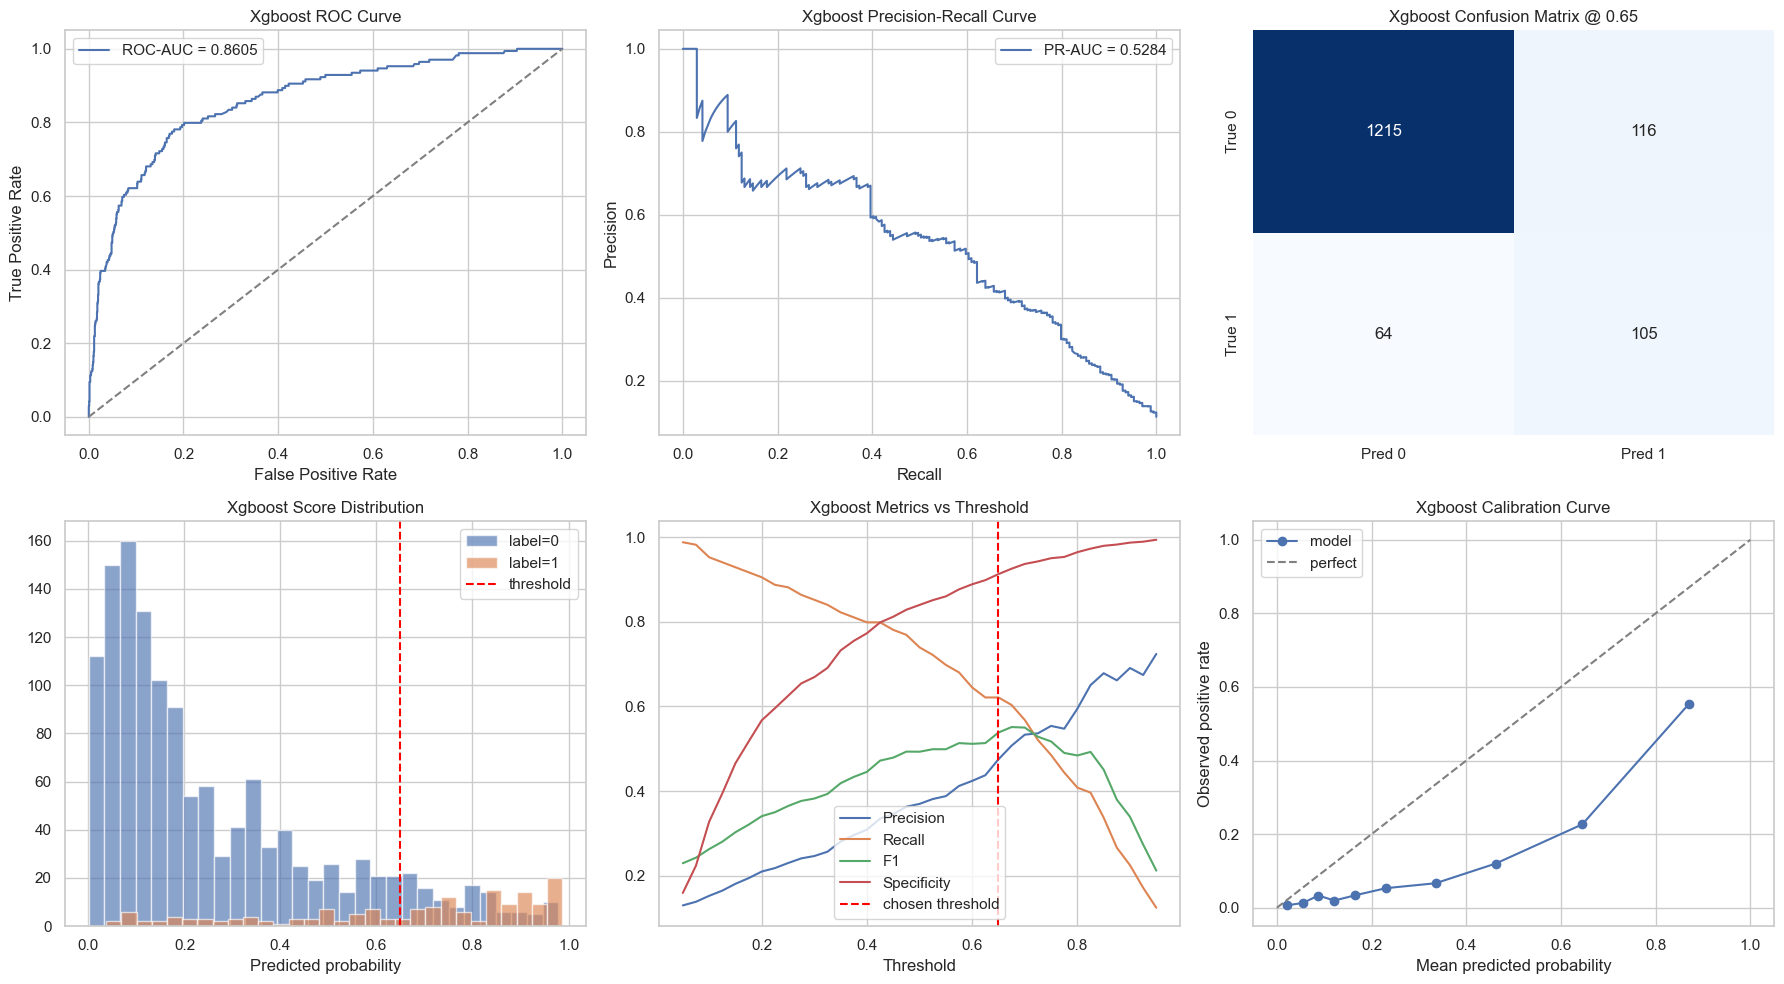

In [7]:
plot_evaluation_dashboard(
    y_true=dataset["y_test"].to_numpy(),
    y_prob=result["test_prob"],
    threshold=result["threshold"],
    title_prefix=MODEL_NAME.replace("_", " ").title(),
)


In [8]:
test_node_rows = dataset["nodes_df"].loc[dataset["test_idx"]].copy()
test_node_rows["predicted_probability"] = result["test_prob"]
test_node_rows["predicted_label"] = (result["test_prob"] >= result["threshold"]).astype(int)
suspicious_wallets = test_node_rows.sort_values("predicted_probability", ascending=False).head(25)
display(
    suspicious_wallets[
        [
            "node_id",
            "label",
            "predicted_probability",
            "predicted_label",
            "full_total_degree",
            "sub_total_degree",
        ]
    ]
)


,node_id,label,predicted_probability,predicted_label,full_total_degree,sub_total_degree
1539,204115,1,0.987009,1,1,1
1834,235606,1,0.986589,1,5,5
2046,258361,1,0.985843,1,2,0
2209,276703,1,0.983499,1,1,0
1664,217839,1,0.983439,1,11,8
2200,275857,0,0.978464,1,65,7
2732,341302,1,0.978302,1,4,2
9227,1190237,1,0.978267,1,1,1
4407,547257,0,0.978231,1,86,24
9914,1259267,1,0.976327,1,1,1


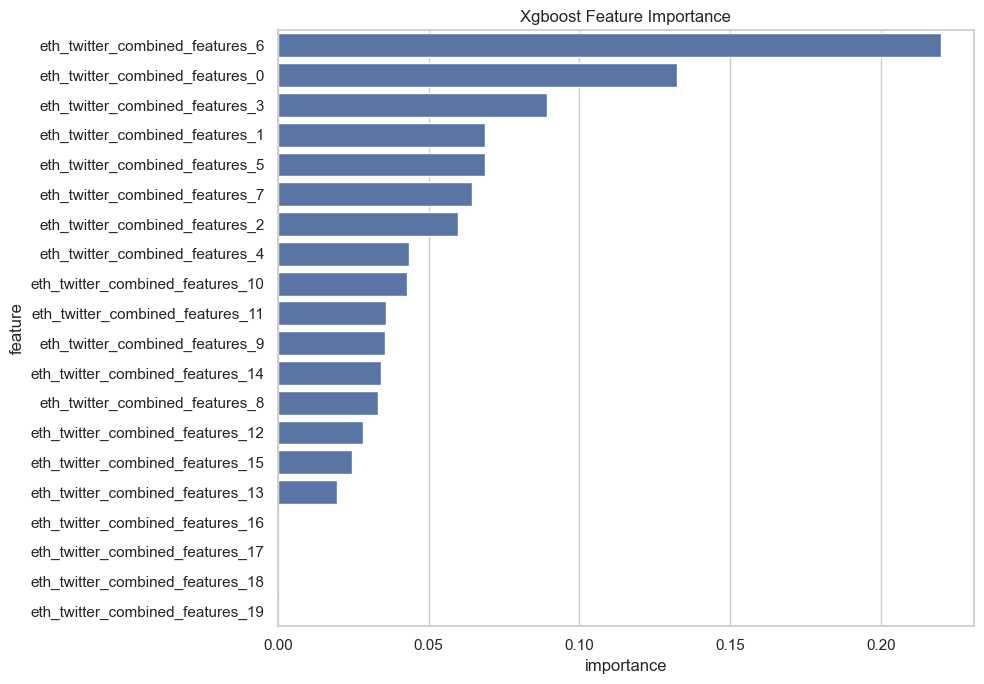

,feature,importance,signed_value
6,eth_twitter_combined_features_6,0.219827,0.219827
0,eth_twitter_combined_features_0,0.132304,0.132304
3,eth_twitter_combined_features_3,0.089147,0.089147
1,eth_twitter_combined_features_1,0.068828,0.068828
5,eth_twitter_combined_features_5,0.068610,0.068610
7,eth_twitter_combined_features_7,0.064302,0.064302
2,eth_twitter_combined_features_2,0.059614,0.059614
4,eth_twitter_combined_features_4,0.043354,0.043354
10,eth_twitter_combined_features_10,0.042862,0.042862
11,eth_twitter_combined_features_11,0.035775,0.035775


In [9]:
plot_feature_importance(
    model=result["model"],
    feature_cols=dataset["feature_cols"],
    title=f"{MODEL_NAME.replace('_', ' ').title()} Feature Importance",
    top_n=20,
)


## Notes

Use `PR-AUC`, `Recall`, `Precision`, `F1`, `Balanced-Accuracy`, and `MCC` together when comparing this model with the other baselines.
